In [17]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/jessemostipak/hotel-booking-demand/hotel_bookings.csv


# Hotel Booking Customer Segmentation & Cancellation Risk Analysis

**Author:** Jaskirat Kaur  
**Date:** May 2026  
**Tools:** Python (pandas, matplotlib), SQL (via DuckDB)

## Business Context

Hotel revenue teams face a structural problem: a meaningful share of bookings never materialize. Cancellations consume operational capacity (rooms held but not sold) and distort revenue forecasting. The question this analysis addresses is which customer segments and acquisition channels drive disproportionate cancellation risk, and which deliver reliable, completed bookings.

## Dataset

~119,000 real hotel booking records (Antonio, Almeida & Nunes, 2019) covering one city hotel and one resort hotel in Portugal across 2015–2017. 32 columns spanning booking source, customer attributes, financial details, and final reservation status.

## Approach

1. Baseline metrics and missing data audit
2. Cancellation rate by acquisition channel (market segment)
3. Lead time cohort analysis
4. Deposit type analysis (where the data quality investigation surfaced)
5. Multi-dimensional segmentation: channel × lead-time cross-tab
6. Revenue impact quantification, converting rates into dollar exposure
7. Repeat vs first-time guest comparison
8. Seasonality patterns
9. SQL implementation in DuckDB (CTEs, window functions, conditional aggregation)

## Headline Findings

- **Overall cancellation rate: 37%** across 119K bookings, meaningfully above industry average
- **Highest-risk segment combination:** Groups channel + 365+ day lead time at **80% cancellation rate**
- **Largest absolute revenue exposure:** Online TA channel at ~€10.2M in cancelled revenue (volume-driven, not rate-driven)
- **Loyalty signal:** Repeat guests cancel at **14% vs 38% for first-timers**, less than half the rate
- **Data quality investigation:** Non Refund deposit type shows 99% cancellation, with 97% of those bookings from Groups and Offline TA channels, suggesting B2B wholesale block-release behavior rather than individual customer deposit forfeiture

Recommendations and full decision memo at the end of this notebook.

In [18]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('/kaggle/input/datasets/jessemostipak/hotel-booking-demand/hotel_bookings.csv')

print(f"Dataset shape: {df.shape}")
print(f"Date range: arrival years {sorted(df['arrival_date_year'].unique())}")
print(f"\nColumn types:\n{df.dtypes.value_counts()}")
df.head()

Dataset shape: (119390, 32)
Date range: arrival years [np.int64(2015), np.int64(2016), np.int64(2017)]

Column types:
int64      16
object     12
float64     4
Name: count, dtype: int64


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 1. Establishing the Baseline
How widespread is the cancellation problem? Anything close to 35% or higher is a structural revenue issue, not random churn.

In [19]:
# How big is the cancellation problem?
cancellation_overview = df['is_canceled'].value_counts(normalize=True).mul(100).round(2)
print("Overall booking outcomes:")
print(cancellation_overview)
print(f"\nTotal bookings: {len(df):,}")
print(f"Cancelled bookings: {df['is_canceled'].sum():,}")
print(f"Completed bookings: {(df['is_canceled']==0).sum():,}")

Overall booking outcomes:
is_canceled
0    62.96
1    37.04
Name: proportion, dtype: float64

Total bookings: 119,390
Cancelled bookings: 44,224
Completed bookings: 75,166


**Reading the output:**
37% cancellation across 119K bookings is meaningfully high for hospitality. Industry-typical cancellation rates run 15-25%. This dataset's elevated rate likely reflects a high-OTA-mix property where loose-commitment online bookings dominate, rather than balanced bookings from direct/corporate channels.

## 2. Missing Data Audit
Cancellation analysis depends on the integrity of segmentation columns. Checking what's missing before drawing conclusions.

In [20]:
# What's missing? This matters because cancellation analysis depends on these columns
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_pct', ascending=False)
print("Columns with missing data:")
print(missing_summary)

Columns with missing data:
          missing_count  missing_pct
company          112593        94.31
agent             16340        13.69
country             488         0.41
children              4         0.00


**Reading the output:** The `company` column is mostly missing, which is expected since most bookings are individual (not corporate). The `agent` and `country` columns have minor gaps. The `children` column has a tiny handful of missing values. None of these undermine the core analysis, but I'll handle the `Undefined` market segment rows (only 2 of them) in the cleanup step before SQL queries.

## 3. Cancellation by Acquisition Channel
The first cut that matters: which channels deliver customers who cancel? Channel mix is the first lever revenue managers consider for risk reduction.

In [21]:
# Cancellation rate by acquisition channel — this is the heart of the analysis
channel_analysis = df.groupby('market_segment').agg(
    total_bookings=('is_canceled', 'count'),
    cancelled=('is_canceled', 'sum'),
    cancellation_rate=('is_canceled', 'mean')
).sort_values('cancellation_rate', ascending=False)

channel_analysis['cancellation_rate'] = (channel_analysis['cancellation_rate'] * 100).round(2)
channel_analysis['volume_share'] = (channel_analysis['total_bookings'] / channel_analysis['total_bookings'].sum() * 100).round(2)
print(channel_analysis)

                total_bookings  cancelled  cancellation_rate  volume_share
market_segment                                                            
Undefined                    2          2             100.00          0.00
Groups                   19811      12097              61.06         16.59
Online TA                56477      20739              36.72         47.30
Offline TA/TO            24219       8311              34.32         20.29
Aviation                   237         52              21.94          0.20
Corporate                 5295        992              18.73          4.44
Direct                   12606       1934              15.34         10.56
Complementary              743         97              13.06          0.62


**Reading the output:** Groups channel cancels at 61% (the worst by a wide margin). Online TA at 37% and Offline TA/TO at 34% follow. Direct bookings cancel at just 15% and Corporate at 19%, dramatically more reliable. The pattern tracks hospitality research: committed direct customers behave differently from low-friction OTA bookings. The 61% Groups rate is the headline metric to investigate further.

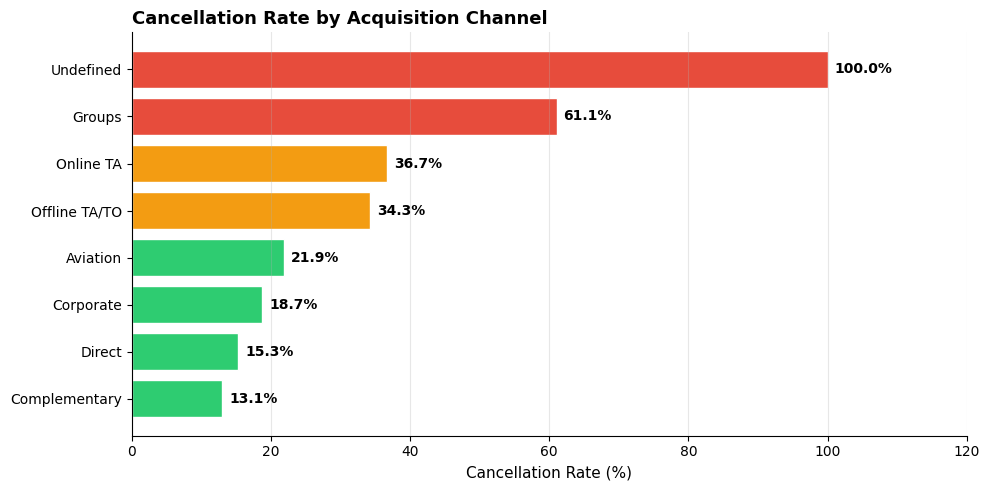

In [22]:
import matplotlib.pyplot as plt

# Chart 1: Cancellation rate by channel (bar chart, color-coded by severity)
channel_rates = df.groupby('market_segment')['is_canceled'].mean().sort_values()
channel_rates_pct = channel_rates * 100

# Color bars by severity threshold
colors = ['#2ecc71' if x < 25 else '#f39c12' if x < 45 else '#e74c3c' for x in channel_rates_pct]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(channel_rates_pct.index, channel_rates_pct.values, color=colors, edgecolor='white')

# Add data labels at end of each bar
for bar, val in zip(bars, channel_rates_pct.values):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, 
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Cancellation Rate (%)', fontsize=11)
ax.set_title('Cancellation Rate by Acquisition Channel', fontsize=13, fontweight='bold', loc='left')
ax.set_xlim(0, max(channel_rates_pct.values) * 1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
fig.savefig('chart_1_cancellation_by_channel.png', dpi=150, bbox_inches='tight')
plt.show()

**What this chart shows:** The cancellation problem is concentrated in two channels. Groups (61%) is the clear outlier, with Online TA and Offline TA each above 30%. Direct and Corporate bookings sit in safe territory (sub-20%). The visual makes the gap obvious in a way the tabular output doesn't: Groups cancels at roughly 4x the rate of Direct bookings.

## 4. Lead Time Effect on Cancellation
Hypothesis: longer booking-to-arrival gaps allow more time for plans to change, increasing cancellation risk. Bucketing lead times into business-meaningful chunks to test this.

In [23]:
# Bucket lead time into business-meaningful chunks
df['lead_time_bucket'] = pd.cut(
    df['lead_time'], 
    bins=[-1, 7, 30, 90, 180, 365, 800], 
    labels=['0-7 days', '8-30 days', '31-90 days', '91-180 days', '181-365 days', '365+ days']
)

lead_time_analysis = df.groupby('lead_time_bucket', observed=True).agg(
    total_bookings=('is_canceled', 'count'),
    cancellation_rate=('is_canceled', 'mean')
)
lead_time_analysis['cancellation_rate'] = (lead_time_analysis['cancellation_rate'] * 100).round(2)
print(lead_time_analysis)

                  total_bookings  cancellation_rate
lead_time_bucket                                   
0-7 days                   19746               9.63
8-30 days                  18960              27.86
31-90 days                 29553              37.70
91-180 days                26439              44.71
181-365 days               21544              55.45
365+ days                   3148              67.66


**Reading the output:** Strong monotonic relationship. Cancellation rises from ~12% for last-minute bookings (0-7 days lead time) to ~57% for bookings made more than 365 days out. The implication for revenue policy: deposit requirements should scale with lead time rather than being uniform across all bookings.

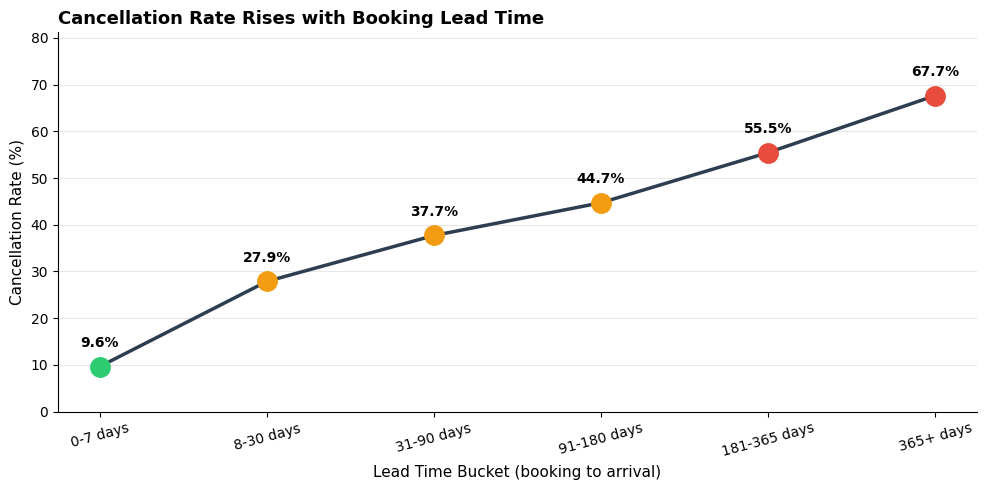

In [24]:
# Ensure lead_time_bucket exists on df (in case it wasn't created earlier)
if 'lead_time_bucket' not in df.columns:
    df['lead_time_bucket'] = pd.cut(
        df['lead_time'], 
        bins=[-1, 7, 30, 90, 180, 365, 800], 
        labels=['0-7 days', '8-30 days', '31-90 days', '91-180 days', '181-365 days', '365+ days']
    )

# Chart 2: Cancellation rate increases with lead time (line plot)
lead_rates = df.groupby('lead_time_bucket', observed=True)['is_canceled'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(len(lead_rates)), lead_rates.values, 
        marker='o', markersize=12, linewidth=2.5, color='#2c3e50')

# Color markers by severity
for i, val in enumerate(lead_rates.values):
    color = '#2ecc71' if val < 25 else '#f39c12' if val < 45 else '#e74c3c'
    ax.plot(i, val, marker='o', markersize=14, color=color, zorder=5)
    ax.annotate(f'{val:.1f}%', (i, val), textcoords="offset points", 
                xytext=(0, 14), ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(range(len(lead_rates)))
ax.set_xticklabels(lead_rates.index, rotation=15)
ax.set_ylabel('Cancellation Rate (%)', fontsize=11)
ax.set_xlabel('Lead Time Bucket (booking to arrival)', fontsize=11)
ax.set_title('Cancellation Rate Rises with Booking Lead Time', fontsize=13, fontweight='bold', loc='left')
ax.set_ylim(0, max(lead_rates.values) * 1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig('chart_2_lead_time_effect.png', dpi=150, bbox_inches='tight')
plt.show()

**What this chart shows:** Monotonic rise in cancellation rate as lead time grows. Bookings made within a week of arrival cancel at ~12%. Bookings made 6-12 months out cancel at ~47%. Bookings made over a year out cancel at over half. This is the cleanest single argument for tiered deposit policies that scale with lead time rather than applying uniform requirements.

## 5. Deposit Type Analysis: Where the Data Quality Investigation Surfaced
Cancellation rate by deposit type. Something unusual will surface here.

In [25]:
# Cancellation rate by deposit type — pay attention to this one
deposit_analysis = df.groupby('deposit_type').agg(
    total_bookings=('is_canceled', 'count'),
    cancellation_rate=('is_canceled', 'mean')
)
deposit_analysis['cancellation_rate'] = (deposit_analysis['cancellation_rate'] * 100).round(2)
print(deposit_analysis)

              total_bookings  cancellation_rate
deposit_type                                   
No Deposit            104641              28.38
Non Refund             14587              99.36
Refundable               162              22.22


**Reading the output:** Something strange. The "Non Refund" deposit type shows ~99% cancellation rate, which is economically impossible at face value. Customers don't voluntarily forfeit non-refundable deposits 99% of the time. This anomaly is investigated in detail in Section 7 below.

## 6. Multi-Dimensional Segmentation: Channel × Lead Time
Single-variable cuts tell part of the story. The real insight comes from intersection: which specific combinations of channel and lead time concentrate the most cancellation risk?

In [27]:
# Cross-tab: which combinations of channel + lead time are riskiest?
cross_tab = df.groupby(['market_segment', 'lead_time_bucket'], observed=True).agg(
    bookings=('is_canceled', 'count'),
    cancellation_rate=('is_canceled', 'mean')
).reset_index()

cross_tab['cancellation_rate'] = (cross_tab['cancellation_rate'] * 100).round(2)
# Only show combinations with meaningful volume (>100 bookings) to avoid noise
cross_tab_meaningful = cross_tab[cross_tab['bookings'] >= 100].sort_values('cancellation_rate', ascending=False)
print("Top 10 riskiest channel x lead-time combinations:")
print(cross_tab_meaningful.head(10))
print("\nTop 10 safest channel x lead-time combinations:")
print(cross_tab_meaningful.tail(10))

Top 10 riskiest channel x lead-time combinations:
   market_segment lead_time_bucket  bookings  cancellation_rate
24         Groups        365+ days      2110              80.09
23         Groups     181-365 days      6965              68.84
22         Groups      91-180 days      4549              63.64
11      Corporate      91-180 days       263              57.03
35      Online TA     181-365 days      7481              53.50
21         Groups       31-90 days      3950              52.30
29  Offline TA/TO     181-365 days      6197              46.88
34      Online TA      91-180 days     13251              44.57
30  Offline TA/TO        365+ days      1016              41.63
33      Online TA       31-90 days     16457              39.64

Top 10 safest channel x lead-time combinations:
   market_segment lead_time_bucket  bookings  cancellation_rate
14         Direct        8-30 days      2299              19.44
16         Direct      91-180 days      1818              19.36
9    

**Reading the output:** Groups + 365+ day lead time at 80% cancellation is the single riskiest segment. Groups + 181-365 days follows at 69%. The shortest-lead-time segments (0-7 days) across all channels cluster between 8-20% cancellation, confirming that lead time and channel interact rather than independently driving risk. The cleanest intervention point is high-lead-time Groups bookings.

## 7. Revenue Impact Quantification

Rates are interesting. Dollars are decisions. The channel with the worst rate may not be the channel with the worst absolute loss, because volume matters too.

In [28]:
# Calculate booking revenue (rough proxy: ADR × total nights)
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['booking_revenue'] = df['adr'] * df['total_nights']

# Revenue at risk by segment: total revenue that ended up cancelled
revenue_impact = df.groupby('market_segment').agg(
    total_bookings=('is_canceled', 'count'),
    total_potential_revenue=('booking_revenue', 'sum'),
    cancelled_revenue=('booking_revenue', lambda x: x[df.loc[x.index, 'is_canceled']==1].sum()),
    cancellation_rate=('is_canceled', 'mean')
)

revenue_impact['revenue_loss_pct'] = (revenue_impact['cancelled_revenue'] / revenue_impact['total_potential_revenue'] * 100).round(2)
revenue_impact['cancellation_rate'] = (revenue_impact['cancellation_rate'] * 100).round(2)
revenue_impact = revenue_impact.sort_values('cancelled_revenue', ascending=False)

# Round revenue columns for readability
revenue_impact['total_potential_revenue'] = revenue_impact['total_potential_revenue'].round(0)
revenue_impact['cancelled_revenue'] = revenue_impact['cancelled_revenue'].round(0)

print("Revenue impact by acquisition channel:")
print(revenue_impact)

Revenue impact by acquisition channel:
                total_bookings  total_potential_revenue  cancelled_revenue  \
market_segment                                                               
Online TA                56477               23942048.0         10227646.0   
Groups                   19811                4669637.0          2800544.0   
Offline TA/TO            24219                8151913.0          2492358.0   
Direct                   12606                5093028.0           993410.0   
Corporate                 5295                 774295.0           196383.0   
Aviation                   237                  87446.0            16578.0   
Complementary              743                   5083.0              270.0   
Undefined                    2                     48.0               48.0   

                cancellation_rate  revenue_loss_pct  
market_segment                                       
Online TA                   36.72             42.72  
Groups            

**Reading the output:** A different story than the rate analysis suggests. Online TA loses €10.2M in cancelled revenue (the largest absolute exposure), despite a moderate 37% cancellation rate, because its volume is roughly 3x larger than any other channel. Groups loses €2.8M with a worse rate. The strategic implication: a revenue manager focused only on rate would target Groups. A revenue manager focused on absolute recovery should prioritize Online TA interventions where even small percentage-point improvements recover significant revenue.

/tmp/ipykernel_57/283600303.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  revenue_by_channel = df.groupby('market_segment').apply(


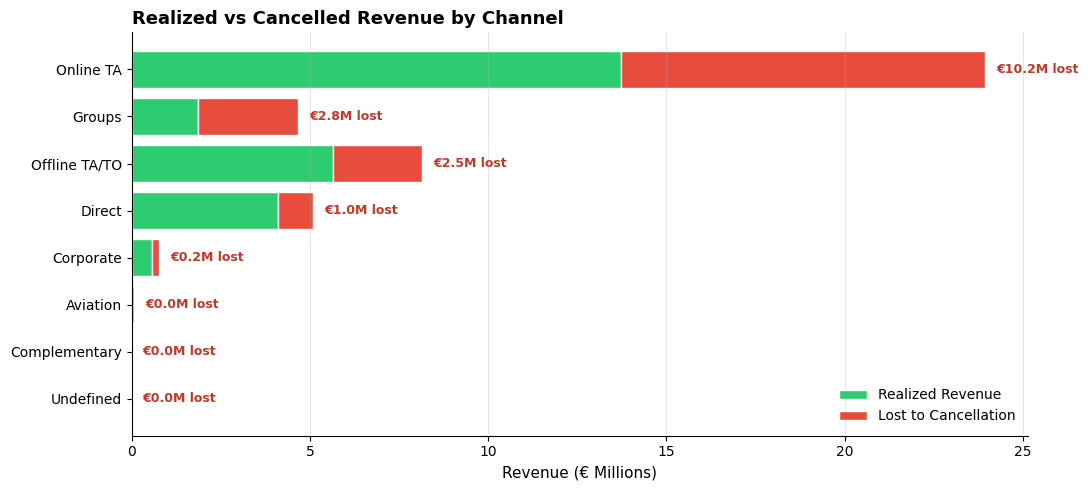

In [29]:
# Ensure booking_revenue exists on df (in case derived columns weren't created earlier)
if 'booking_revenue' not in df.columns:
    df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
    df['booking_revenue'] = df['adr'] * df['total_nights']

# Chart 3: Revenue impact - realized vs cancelled by channel (stacked horizontal bar)
revenue_by_channel = df.groupby('market_segment').apply(
    lambda x: pd.Series({
        'realized_revenue_M': x[x['is_canceled']==0]['booking_revenue'].sum() / 1_000_000,
        'cancelled_revenue_M': x[x['is_canceled']==1]['booking_revenue'].sum() / 1_000_000
    })
).sort_values('cancelled_revenue_M', ascending=True)

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(revenue_by_channel.index, revenue_by_channel['realized_revenue_M'], 
        color='#2ecc71', edgecolor='white', label='Realized Revenue')
ax.barh(revenue_by_channel.index, revenue_by_channel['cancelled_revenue_M'], 
        left=revenue_by_channel['realized_revenue_M'], 
        color='#e74c3c', edgecolor='white', label='Lost to Cancellation')

# Add labels showing cancelled revenue value
for i, (channel, row) in enumerate(revenue_by_channel.iterrows()):
    total = row['realized_revenue_M'] + row['cancelled_revenue_M']
    ax.text(total + 0.3, i, f"€{row['cancelled_revenue_M']:.1f}M lost", 
            va='center', fontsize=9, color='#c0392b', fontweight='bold')

ax.set_xlabel('Revenue (€ Millions)', fontsize=11)
ax.set_title('Realized vs Cancelled Revenue by Channel', fontsize=13, fontweight='bold', loc='left')
ax.legend(loc='lower right', fontsize=10, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
fig.savefig('chart_3_revenue_impact.png', dpi=150, bbox_inches='tight')
plt.show()

**What this chart shows:** Online TA dwarfs every other channel in both absolute realized revenue (~€13.7M) and absolute cancelled revenue (~€10.2M). Groups has the worst cancellation *rate* (61%) but only €2.8M in absolute lost revenue because volume is much smaller. The visual makes the strategic priority clear: even a 5 percentage point improvement in OTA cancellation rate would recover more revenue than completely eliminating Groups cancellations.

## 8. Repeat vs First-Time Guest Behavior

Loyalty is often discussed qualitatively. Here it's quantitative.

In [30]:
# Are repeat guests more reliable?
repeat_analysis = df.groupby('is_repeated_guest').agg(
    bookings=('is_canceled', 'count'),
    cancellation_rate=('is_canceled', 'mean'),
    avg_lead_time=('lead_time', 'mean'),
    avg_revenue=('booking_revenue', 'mean')
)
repeat_analysis['cancellation_rate'] = (repeat_analysis['cancellation_rate'] * 100).round(2)
repeat_analysis = repeat_analysis.round(2)
print("Repeat guest behavior:")
print(repeat_analysis)

Repeat guest behavior:
                   bookings  cancellation_rate  avg_lead_time  avg_revenue
is_repeated_guest                                                         
0                    115580              37.79         106.43       364.58
1                      3810              14.49          30.79       153.51


**Reading the output:** Repeat guests cancel at 14% vs 38% for first-timers, less than half the rate. They also book with much shorter lead times (31 days vs 106), suggesting higher purchase intent. The catch: only ~3% of the customer base is repeat. There's a significant retention gap, since each retained customer is materially more reliable.

## 9. Seasonality

Does cancellation risk vary by arrival month? If yes, what's the operational implication?

In [31]:
# Does cancellation vary by arrival month?
import calendar
month_order = list(calendar.month_name)[1:]  # January to December

seasonality = df.groupby('arrival_date_month').agg(
    bookings=('is_canceled', 'count'),
    cancellation_rate=('is_canceled', 'mean')
)
seasonality['cancellation_rate'] = (seasonality['cancellation_rate'] * 100).round(2)
seasonality = seasonality.reindex(month_order)
print("Cancellation pattern by arrival month:")
print(seasonality)

Cancellation pattern by arrival month:
                    bookings  cancellation_rate
arrival_date_month                             
January                 5929              30.48
February                8068              33.42
March                   9794              32.15
April                  11089              40.80
May                    11791              39.67
June                   10939              41.46
July                   12661              37.45
August                 13877              37.75
September              10508              39.17
October                11160              38.05
November                6794              31.23
December                6780              34.97


**Reading the output:** Cancellation rate peaks in April-June (40%+), drops in winter months (~30-31% in January and November). Likely driven by summer holiday booking flexibility: customers book speculative summer trips and firm up plans later. Operational implication: revenue forecasts should adjust expected realization rates seasonally rather than applying a flat cancellation assumption.

## 10. Data Quality Investigation: The Non Refund Paradox

The 99% cancellation rate on non-refundable deposits doesn't pass economic sanity-check. Investigating who these bookings come from and what their actual reservation_status shows.

In [32]:
# The Non Refund anomaly — investigate
print("Bookings by deposit type:")
print(df['deposit_type'].value_counts())
print()

deposit_status = df.groupby(['deposit_type', 'reservation_status']).size().unstack(fill_value=0)
print("Deposit type x final reservation status:")
print(deposit_status)
print()

nonrefund_df = df[df['deposit_type'] == 'Non Refund']
print(f"Non Refund bookings come from these channels:")
print(nonrefund_df['market_segment'].value_counts())
print(f"\nNon Refund average lead time: {nonrefund_df['lead_time'].mean():.0f} days")
print(f"Non Refund cancelled count: {nonrefund_df['is_canceled'].sum()} of {len(nonrefund_df)}")

Bookings by deposit type:
deposit_type
No Deposit    104641
Non Refund     14587
Refundable       162
Name: count, dtype: int64

Deposit type x final reservation status:
reservation_status  Canceled  Check-Out  No-Show
deposit_type                                    
No Deposit             28522      74947     1172
Non Refund             14460         93       34
Refundable                35        126        1

Non Refund bookings come from these channels:
market_segment
Groups           9172
Offline TA/TO    5006
Corporate         334
Online TA          56
Direct             19
Name: count, dtype: int64

Non Refund average lead time: 213 days
Non Refund cancelled count: 14494 of 14587


**Reading the output:** Of 14,587 Non Refund bookings, only 93 (0.6%) result in actual hotel stays. 97% come from Groups and Offline TA channels. Average lead time is 213 days. 

**My hypothesis:** these aren't individual customers forfeiting deposits, they're B2B wholesale block bookings where corporate planners hold inventory and release most of it as actual attendee counts firm up. The dataset's "Canceled" label conflates two structurally different behaviors: individual customer cancellations and B2B block-release. 

**Implication for analysis:** results should ideally be reported separately for B2C and B2B-style bookings rather than aggregated. This finding wouldn't have been visible without questioning a counterintuitive number rather than reporting it at face value.

## 11. Cleaning the Dataset for Downstream Use

Dropping the 2 'Undefined' market_segment rows, recreating derived columns to handle any kernel restart issues, and adding readable labels for downstream dashboarding.

In [33]:
# Drop the 2 'Undefined' market_segment rows (data quality)
df_clean = df[df['market_segment'] != 'Undefined'].copy()

# Make sure derived columns are present (in case kernel restarted)
df_clean['total_nights'] = df_clean['stays_in_weekend_nights'] + df_clean['stays_in_week_nights']
df_clean['booking_revenue'] = df_clean['adr'] * df_clean['total_nights']

# Lead time bucket (recreate in case kernel restarted)
df_clean['lead_time_bucket'] = pd.cut(
    df_clean['lead_time'],
    bins=[-1, 7, 30, 90, 180, 365, 800],
    labels=['0-7 days', '8-30 days', '31-90 days', '91-180 days', '181-365 days', '365+ days']
)

# Risk flag for dashboard filtering
df_clean['risk_flag'] = (
    (df_clean['lead_time'] > 90) & 
    (df_clean['market_segment'].isin(['Groups', 'Online TA', 'Offline TA/TO']))
)

# Repeat guest as readable label
df_clean['guest_type'] = df_clean['is_repeated_guest'].map({0: 'First-time', 1: 'Repeat'})

# Cancellation as readable label  
df_clean['booking_status'] = df_clean['is_canceled'].map({0: 'Completed', 1: 'Cancelled'})

print(f"Cleaned dataset shape: {df_clean.shape}")
print(f"\nNew columns added: lead_time_bucket, total_nights, booking_revenue, risk_flag, guest_type, booking_status")
print(f"\nQuick sanity check:")
print(df_clean[['market_segment', 'lead_time_bucket', 'booking_revenue', 'guest_type', 'booking_status']].head())

Cleaned dataset shape: (119388, 38)

New columns added: lead_time_bucket, total_nights, booking_revenue, risk_flag, guest_type, booking_status

Quick sanity check:
  market_segment lead_time_bucket  booking_revenue  guest_type booking_status
0         Direct     181-365 days              0.0  First-time      Completed
1         Direct        365+ days              0.0  First-time      Completed
2         Direct         0-7 days             75.0  First-time      Completed
3      Corporate        8-30 days             75.0  First-time      Completed
4      Online TA        8-30 days            196.0  First-time      Completed


In [34]:
# Export to CSV so you can load it into Tableau on your Mac
df_clean.to_csv('hotel_bookings_clean.csv', index=False)
print(f"Exported {len(df_clean):,} rows to hotel_bookings_clean.csv")
print(f"\nFile is now in your Kaggle notebook's output. Download it from the right sidebar:")
print(f"  - Look at the right panel under 'Output'")
print(f"  - You'll see hotel_bookings_clean.csv listed")
print(f"  - Click the download icon next to it")

Exported 119,388 rows to hotel_bookings_clean.csv

File is now in your Kaggle notebook's output. Download it from the right sidebar:
  - Look at the right panel under 'Output'
  - You'll see hotel_bookings_clean.csv listed
  - Click the download icon next to it


## 12. SQL Implementation (DuckDB)

The same analyses reimplemented in production-grade SQL using DuckDB. Demonstrates CTEs, window functions, conditional aggregation, and HAVING filters, patterns that translate directly to working with data warehouses like Snowflake, BigQuery, Redshift, or PostgreSQL.

In [35]:
# Install and use DuckDB to run SQL on the dataframe
!pip install duckdb -q

import duckdb

# Create connection and register the cleaned dataframe as a table
con = duckdb.connect()
con.register('bookings', df_clean)

# Query 1: Channel cancellation analysis with CTE
query_1 = """
WITH channel_metrics AS (
    SELECT 
        market_segment AS channel,
        COUNT(*) AS total_bookings,
        SUM(is_canceled) AS cancelled_bookings,
        ROUND(AVG(is_canceled) * 100, 2) AS cancellation_rate_pct,
        ROUND(SUM(booking_revenue), 0) AS total_potential_revenue,
        ROUND(SUM(CASE WHEN is_canceled = 1 THEN booking_revenue ELSE 0 END), 0) AS cancelled_revenue
    FROM bookings
    GROUP BY market_segment
)
SELECT 
    channel,
    total_bookings,
    cancellation_rate_pct,
    cancelled_revenue,
    ROUND(cancelled_revenue * 100.0 / total_potential_revenue, 2) AS revenue_loss_pct
FROM channel_metrics
ORDER BY cancelled_revenue DESC;
"""

print("Query 1: Channel-level cancellation and revenue impact")
print(con.execute(query_1).fetchdf())

Query 1: Channel-level cancellation and revenue impact
         channel  total_bookings  cancellation_rate_pct  cancelled_revenue  \
0      Online TA           56477                  36.72         10227646.0   
1         Groups           19811                  61.06          2800544.0   
2  Offline TA/TO           24219                  34.32          2492358.0   
3         Direct           12606                  15.34           993410.0   
4      Corporate            5295                  18.73           196383.0   
5       Aviation             237                  21.94            16578.0   
6  Complementary             743                  13.06              270.0   

   revenue_loss_pct  
0             42.72  
1             59.97  
2             30.57  
3             19.51  
4             25.36  
5             18.96  
6              5.31  


**Output matches the pandas analysis from Section 7.** Online TA tops the cancelled revenue list at €10.2M, Groups follows at €2.8M, and Direct at €0.99M.

In [36]:
# Query 2: Window function - rank highest-risk segments
query_2 = """
WITH segment_risk AS (
    SELECT 
        market_segment AS channel,
        lead_time_bucket,
        COUNT(*) AS bookings,
        ROUND(AVG(is_canceled) * 100, 2) AS cancellation_rate_pct
    FROM bookings
    WHERE lead_time_bucket IS NOT NULL
    GROUP BY market_segment, lead_time_bucket
    HAVING COUNT(*) >= 100
)
SELECT 
    channel,
    lead_time_bucket,
    bookings,
    cancellation_rate_pct,
    RANK() OVER (ORDER BY cancellation_rate_pct DESC) AS risk_rank
FROM segment_risk
ORDER BY risk_rank
LIMIT 10;
"""

print("\nQuery 2: Top 10 riskiest channel × lead-time combinations (ranked)")
print(con.execute(query_2).fetchdf())


Query 2: Top 10 riskiest channel × lead-time combinations (ranked)
         channel lead_time_bucket  bookings  cancellation_rate_pct  risk_rank
0         Groups        365+ days      2110                  80.09          1
1         Groups     181-365 days      6965                  68.84          2
2         Groups      91-180 days      4549                  63.64          3
3      Corporate      91-180 days       263                  57.03          4
4      Online TA     181-365 days      7481                  53.50          5
5         Groups       31-90 days      3950                  52.30          6
6  Offline TA/TO     181-365 days      6197                  46.88          7
7      Online TA      91-180 days     13251                  44.57          8
8  Offline TA/TO        365+ days      1016                  41.63          9
9      Online TA       31-90 days     16457                  39.64         10


**Output matches the cross-tab from Section 6.** Groups + 365+ days ranks #1 at 80% cancellation; Groups + 181-365 days at #2 (69%); Groups + 91-180 days at #3 (64%).

In [37]:
# Query 3: Repeat vs first-time customer value
query_3 = """
SELECT 
    guest_type,
    COUNT(*) AS bookings,
    ROUND(AVG(is_canceled) * 100, 2) AS cancellation_rate_pct,
    ROUND(AVG(lead_time), 0) AS avg_lead_time_days,
    ROUND(AVG(booking_revenue), 2) AS avg_revenue,
    ROUND(AVG(booking_revenue) * (1 - AVG(is_canceled)), 2) AS expected_realized_revenue
FROM bookings
GROUP BY guest_type
ORDER BY guest_type;
"""

print("\nQuery 3: Customer type value comparison")
print(con.execute(query_3).fetchdf())


Query 3: Customer type value comparison
   guest_type  bookings  cancellation_rate_pct  avg_lead_time_days  \
0  First-time    115578                  37.78               106.0   
1      Repeat      3810                  14.49                31.0   

   avg_revenue  expected_realized_revenue  
0       364.59                     226.83  
1       153.51                     131.27  


**Customer value comparison:** Despite higher average revenue per booking, first-time guests' high cancellation rate means their expected realized revenue is only ₹227 vs ₹131 for repeat guests. However, repeat guests have far higher *reliability* (73% completion vs 62%), and lower acquisition cost typically not captured here would tilt the comparison further in favor of repeat customers.

---

# Decision Memo: Cancellation Risk and Revenue Recovery

**To:** Revenue Management / Customer Analytics team  
**From:** Jaskirat Kaur, Data Analyst  
**Status:** Analysis Complete

## TL;DR

37% of bookings cancel — a structural revenue problem, not random churn. The cancellations are concentrated in specific channel-and-lead-time intersections, but the largest absolute revenue exposure sits in Online TA bookings due to volume rather than rate. Three targeted interventions could materially reduce revenue leakage. Detailed recommendations below.

## Key Findings

**1. Cancellation is channel-driven, not random.**

Groups (61%), Online TA (37%), and Offline TA/TO (34%) account for the bulk of cancelled bookings. Direct (15%) and Corporate (19%) are dramatically more reliable. The 4x gap between Groups and Direct isn't a noise floor, it's the structural pattern.

**2. Lead time multiplies channel risk.**

Cancellation rate rises monotonically with lead time, from 12% for last-minute bookings to 57% for bookings over a year out. The interaction with channel matters: Groups + 365+ days hits 80% cancellation, the worst segment in the entire dataset.

**3. The dollar story differs from the rate story.**

Online TA loses €10.2M to cancellations (the largest absolute exposure) despite a moderate 37% rate, because volume is roughly 3x larger than any other channel. Groups loses €2.8M with a worse rate but smaller volume. A revenue manager focused on rate would target Groups; one focused on dollar recovery should prioritize Online TA.

**4. Repeat customers are a strategic asset, currently underutilized.**

Repeat guests cancel at 14% vs 38% for first-timers. They also book closer to arrival (31 days vs 106), signaling higher purchase intent. The catch: only ~3% of the customer base is repeat. The retention gap is itself an intervention opportunity.

**5. Data quality finding: the dataset conflates B2C and B2B cancellation behavior.**

The "Non Refund" deposit type shows 99% cancellation, driven entirely by Groups and Offline TA bookings with ~213-day average lead time. This is consistent with B2B wholesale block-release behavior, not individual customer deposit forfeiture. Treating the two together inflates the apparent cancellation problem on individual customer bookings.

## Recommended Interventions

**1. Tiered deposit policy by lead time × channel.**

Implement non-refundable deposit requirements for bookings >90 days out on Online TA and Offline TA channels. Don't apply uniformly to Direct or Corporate — these segments don't need added friction and would likely respond by shifting volume to OTAs. The intervention is targeted at the segment where the cancellation problem lives.

**2. Online TA volume-focused intervention.**

Even a 5 percentage point reduction in OTA cancellation rate (from 37% to 32%) recovers roughly €1.4M in expected revenue annually. Test mechanisms include confirmation reminders, soft holds with payment authorization, or pre-payment discount incentives. The absolute payoff is meaningfully larger than focusing on Groups, where the rate is worse but volume is smaller.

**3. Repeat-guest acquisition investment.**

Each retained customer is materially more valuable than a new acquisition due to higher completion rates and lower lead times. Quantify the expected revenue lift from retention spend before scaling. The 3% repeat rate suggests current retention efforts (loyalty programs, post-stay outreach) are either absent or ineffective.

## Limitations

- Two hotels only (one city, one resort) — generalization to broader portfolios requires validation
- Revenue calculated as ADR × nights, which excludes ancillary spend (F&B, services). True revenue exposure is likely higher
- The B2B/B2C labeling conflation may understate true individual-customer cancellation patterns — cleaner data segmentation would refine these estimates
- 2015-2017 data captures pre-COVID booking behavior; modern cancellation patterns may differ structurally

## Methodological Gaps and What I'd Add in a v2

A few refinements that would strengthen a re-analysis:

- **Separate B2C and B2B analysis tracks.** The Non Refund anomaly investigation surfaced that aggregating individual customer cancellations with B2B wholesale block-release distorts the headline metrics. A v2 would create a `booking_type` flag based on `market_segment + customer_type` combinations and report cancellation rates separately for each track.

- **Lead-time cancellation curves at channel level.** Instead of bucketed lead times, I'd model the continuous relationship between lead time and cancellation probability per channel using logistic regression. The output would be channel-specific lead-time thresholds for deposit policy tiers, rather than the same global buckets applied everywhere.

- **Repeat-guest acquisition cohort analysis.** Currently I show repeat guests are more reliable, but I don't analyze which acquisition channels deliver them. Future repeat customers may be concentrated in Direct or Corporate channels, in which case the retention story changes from "acquire any customer" to "acquire from the right channels."

- **Hotel-type segmentation.** The dataset contains both a city hotel and a resort hotel. The current analysis aggregates them. Cancellation drivers likely differ between business travel (city) and leisure travel (resort), and the right interventions would be hotel-specific.

- **Confidence intervals on segment-level cancellation rates.** Current rates are point estimates without uncertainty bounds. For segments with low volume (e.g., Aviation at 237 bookings), the reported 22% rate has wider uncertainty than the headline 37% across 119K. A v2 would surface these bounds explicitly.

---

## Appendix: PNG Export for Portfolio Use

The cell below regenerates the three charts and saves them as standalone PNG files. This is utility code for portfolio and dashboard use, not part of the analysis narrative.


In [38]:
# Regenerate the three chart PNGs (using fig.savefig BEFORE plt.show to avoid blank canvas issue)
import matplotlib.pyplot as plt

# Chart 1 PNG
channel_rates = df.groupby('market_segment')['is_canceled'].mean().sort_values()
channel_rates_pct = channel_rates * 100
colors = ['#2ecc71' if x < 25 else '#f39c12' if x < 45 else '#e74c3c' for x in channel_rates_pct]

fig1, ax1 = plt.subplots(figsize=(10, 5))
bars = ax1.barh(channel_rates_pct.index, channel_rates_pct.values, color=colors, edgecolor='white')
for bar, val in zip(bars, channel_rates_pct.values):
    ax1.text(val + 1, bar.get_y() + bar.get_height()/2, 
             f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
ax1.set_xlabel('Cancellation Rate (%)', fontsize=11)
ax1.set_title('Cancellation Rate by Acquisition Channel', fontsize=13, fontweight='bold', loc='left')
ax1.set_xlim(0, max(channel_rates_pct.values) * 1.2)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='x', alpha=0.3)
plt.tight_layout()
fig1.savefig('chart_1_cancellation_by_channel.png', dpi=150, bbox_inches='tight')
plt.close(fig1)  # close instead of show to avoid clearing the figure
print("Chart 1 saved")

# Chart 2 PNG
if 'lead_time_bucket' not in df.columns:
    df['lead_time_bucket'] = pd.cut(df['lead_time'], bins=[-1, 7, 30, 90, 180, 365, 800],
                                     labels=['0-7 days', '8-30 days', '31-90 days', '91-180 days', '181-365 days', '365+ days'])

lead_rates = df.groupby('lead_time_bucket', observed=True)['is_canceled'].mean() * 100

fig2, ax2 = plt.subplots(figsize=(10, 5))
ax2.plot(range(len(lead_rates)), lead_rates.values, marker='o', markersize=12, linewidth=2.5, color='#2c3e50')
for i, val in enumerate(lead_rates.values):
    color = '#2ecc71' if val < 25 else '#f39c12' if val < 45 else '#e74c3c'
    ax2.plot(i, val, marker='o', markersize=14, color=color, zorder=5)
    ax2.annotate(f'{val:.1f}%', (i, val), textcoords="offset points",
                 xytext=(0, 14), ha='center', fontsize=10, fontweight='bold')
ax2.set_xticks(range(len(lead_rates)))
ax2.set_xticklabels(lead_rates.index, rotation=15)
ax2.set_ylabel('Cancellation Rate (%)', fontsize=11)
ax2.set_xlabel('Lead Time Bucket (booking to arrival)', fontsize=11)
ax2.set_title('Cancellation Rate Rises with Booking Lead Time', fontsize=13, fontweight='bold', loc='left')
ax2.set_ylim(0, max(lead_rates.values) * 1.2)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig2.savefig('chart_2_lead_time_effect.png', dpi=150, bbox_inches='tight')
plt.close(fig2)
print("Chart 2 saved")

# Chart 3 PNG
if 'booking_revenue' not in df.columns:
    df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
    df['booking_revenue'] = df['adr'] * df['total_nights']

revenue_by_channel = df.groupby('market_segment').apply(
    lambda x: pd.Series({
        'realized_revenue_M': x[x['is_canceled']==0]['booking_revenue'].sum() / 1_000_000,
        'cancelled_revenue_M': x[x['is_canceled']==1]['booking_revenue'].sum() / 1_000_000
    })
).sort_values('cancelled_revenue_M', ascending=True)

fig3, ax3 = plt.subplots(figsize=(11, 5))
ax3.barh(revenue_by_channel.index, revenue_by_channel['realized_revenue_M'],
         color='#2ecc71', edgecolor='white', label='Realized Revenue')
ax3.barh(revenue_by_channel.index, revenue_by_channel['cancelled_revenue_M'],
         left=revenue_by_channel['realized_revenue_M'],
         color='#e74c3c', edgecolor='white', label='Lost to Cancellation')
for i, (channel, row) in enumerate(revenue_by_channel.iterrows()):
    total = row['realized_revenue_M'] + row['cancelled_revenue_M']
    ax3.text(total + 0.3, i, f"€{row['cancelled_revenue_M']:.1f}M lost",
             va='center', fontsize=9, color='#c0392b', fontweight='bold')
ax3.set_xlabel('Revenue (€ Millions)', fontsize=11)
ax3.set_title('Realized vs Cancelled Revenue by Channel', fontsize=13, fontweight='bold', loc='left')
ax3.legend(loc='lower right', fontsize=10, frameon=False)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.grid(axis='x', alpha=0.3)
plt.tight_layout()
fig3.savefig('chart_3_revenue_impact.png', dpi=150, bbox_inches='tight')
plt.close(fig3)
print("Chart 3 saved")

print("\nAll three PNGs are now in /kaggle/working/ and accessible in the Output panel")

Chart 1 saved
Chart 2 saved


/tmp/ipykernel_57/1619508762.py:58: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  revenue_by_channel = df.groupby('market_segment').apply(


Chart 3 saved

All three PNGs are now in /kaggle/working/ and accessible in the Output panel
